# TariffWatch: The Economics of the 2025-2026 U.S. Tariff Regime

An end-to-end **pandas + NumPy + visualization** project analyzing one of the
defining economic stories of 2025-2026: the rapid escalation, partial legal
unwinding, and re-escalation of U.S. tariff policy.

### Grounding this in real events

Unlike a purely illustrative dataset, this project is anchored to real,
recent, and still-unfolding events. As of mid-2026:

- Starting in early 2025, the administration imposed sweeping tariffs under
  the **International Emergency Economic Powers Act (IEEPA)** — including
  the broad "reciprocal" tariffs announced in April 2025 — alongside
  separate **Section 232** national-security tariffs on steel, aluminum,
  copper, and autos, and **Section 301** tariffs on specific categories.
- By early 2026, the U.S. average *effective* tariff rate had climbed to
  roughly **17%**, the highest level since the early 1930s, and New York
  Fed research found close to **90% of that added cost was being borne by
  U.S. firms and consumers** rather than foreign exporters (Brookings, Feb
  2026).
- On **February 20, 2026**, the U.S. Supreme Court ruled 6-3 in *Learning
  Resources, Inc. v. Trump* that IEEPA does **not** authorize the president
  to impose open-ended tariffs, striking down the legal basis for the
  broadest tranche of duties — while leaving Section 232 and Section 301
  tariffs untouched (Tax Foundation; Brookings; Holland & Knight, Feb 2026).
- All IEEPA-based tariffs formally terminated on **February 24, 2026**, and
  the administration immediately introduced replacement **Section 122**
  tariffs (a universal ~10% floor, capped at 15% for up to 150 days).
  Analysts estimated this ruling roughly **halved the effective U.S. tariff
  rate to about 5%**, since Section 232/301 duties remained in force
  (Allianz Trade, Feb 2026).
- Tariff relief from the ruling was **uneven by country** — estimated at
  roughly -18 percentage points for Indonesia, -17pp for Brazil, and -15pp
  each for China and Vietnam, versus only -3pp for the EU/UK and -1pp for
  Japan, since those partners had separate negotiated framework agreements
  covering autos and other sectors (Allianz Trade, Feb 2026).
- On **April 2, 2026**, the administration used Section 232 to *raise*
  tariffs on steel, aluminum, and copper products effective April 6, 2026,
  extending them to the full customs value of derivative products (BDO,
  Apr 2026) — illustrating that the story is still actively developing.
- The **fiscal and refund questions are unresolved**: the Penn Wharton
  Budget Model estimated roughly **$165 billion** in IEEPA tariffs had been
  collected through January 2026, with potential refund liability estimated
  as high as **$175 billion**, and a U.S. Court of International Trade
  order on refund procedure was issued and then partly suspended in March
  2026 pending further process (Penn Wharton; BDO, 2026).

> **A note on evidence and interpretation:** tariff policy is a genuinely
> contested area of economics and politics — reasonable economists disagree
> about the appropriate balance between protecting domestic industry,
> national-security supply chains, government revenue, and consumer/import
> prices. This notebook presents the mechanics and the published estimates
> above as reported by the cited sources; it does not take a position on
> whether the policy was net-beneficial. **Two exceptions to that
> neutrality:** the IEEPA-revenue table and the country-level tariff-relief
> estimates below are reproduced as-published, cited to their source. Every
> other dataset in this notebook — the country×product tariff matrix, price
> pass-through, CPI subcomponents, sector employment, and state-level trade
> exposure — is **synthetic, illustrative data calibrated to be broadly
> consistent with the aggregate published figures above**, built so the
> full analytical pipeline can run without needing a live data subscription
> (e.g. to USITC DataWeb, BLS, or Census trade data).

### What this notebook covers
1. Real reference data: IEEPA revenue collections and country-level relief
2. Building calibrated synthetic datasets (tariff matrix, CPI, employment, trade exposure, policy timeline)
3. Effective tariff rate computation (NumPy broadcasting & aggregation)
4. Price pass-through & landed-cost analysis (ufuncs, boolean masking)
5. Inflation & Fed-policy time series, annotated against the real event timeline
6. Sector employment impact (groupby, statistical comparison)
7. State-level geographic trade exposure (bubble map)
8. Country-level tariff-relief ranking (sorting & fancy indexing, real data)
9. Fiscal impact: revenue vs. refund liability (real data)
10. A one-page executive dashboard
11. Wrap-up, caveats, and further resources


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2026)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data

These two small tables are reproduced from published sources rather than
simulated — everything else in the notebook builds *around* them.


In [2]:
# ---------------------------------------------------------------
# REAL DATA: Monthly IEEPA tariff revenue collections, Jan 2025-Jan 2026
# Source: Penn Wharton Budget Model, "Supreme Court Tariff Ruling: IEEPA
# Revenue and Potential Refunds" (Feb 20, 2026), based on U.S. International
# Trade Commission DataWeb, CBP trade statistics, and U.S. Treasury Daily
# Statement data. Figures are in USD billions.
# ---------------------------------------------------------------
ieepa_revenue = pd.DataFrame({
    "month": pd.period_range("2025-01", "2026-01", freq="M").to_timestamp(),
    "monthly_revenue_usd_bn": [0.00, 0.81, 5.45, 9.42, 13.07, 12.51, 15.35,
                                15.15, 18.79, 19.26, 15.93, 18.17, 20.80],
})
ieepa_revenue["cumulative_revenue_usd_bn"] = ieepa_revenue["monthly_revenue_usd_bn"].cumsum()
ieepa_revenue


,month,monthly_revenue_usd_bn,cumulative_revenue_usd_bn
0,2025-01-01,0.00,0.00
1,2025-02-01,0.81,0.81
2,2025-03-01,5.45,6.26
3,2025-04-01,9.42,15.68
4,2025-05-01,13.07,28.75
5,2025-06-01,12.51,41.26
6,2025-07-01,15.35,56.61
7,2025-08-01,15.15,71.76
8,2025-09-01,18.79,90.55
9,2025-10-01,19.26,109.81


In [3]:
# ---------------------------------------------------------------
# REAL DATA: Estimated change in effective tariff rate by country/bloc
# following the Feb 20, 2026 Supreme Court ruling striking down IEEPA
# tariffs (Section 232/301 tariffs, and negotiated framework agreements
# for some partners, remained in place).
# Source: Allianz Trade, "US Supreme Court IEEPA Tariffs" analysis, 2026.
# ---------------------------------------------------------------
country_relief = pd.DataFrame({
    "country_bloc": ["Indonesia", "Brazil", "China", "Vietnam", "South Africa",
                       "Turkiye", "India", "European Union", "United Kingdom",
                       "Japan", "Mexico", "Saudi Arabia"],
    "effective_tariff_change_pp": [-18, -17, -15, -15, -12, -10, -9,
                                      -3, -3, -1, +2, +2],
})
country_relief.sort_values("effective_tariff_change_pp")


,country_bloc,effective_tariff_change_pp
0,Indonesia,-18
1,Brazil,-17
2,China,-15
3,Vietnam,-15
4,South Africa,-12
5,Turkiye,-10
6,India,-9
7,European Union,-3
8,United Kingdom,-3
9,Japan,-1


## 2. Building the calibrated synthetic datasets

Each of the following is synthetic but **calibrated**: means, trends, and
timing are set to match the qualitative direction and rough magnitude of
the real published estimates cited in the introduction.


In [4]:
# ---------------------------------------------------------------
# A) COUNTRY x PRODUCT TARIFF-RATE MATRIX, pre- and post-ruling
#    Calibrated so the TRADE-WEIGHTED average lands near the published
#    ~17% (pre-ruling) and ~5-8% (post-ruling, Section 232/301 still active)
#    effective tariff rates.
# ---------------------------------------------------------------
trade_countries = np.array(["China", "Mexico", "Canada", "European Union", "Japan",
                              "South Korea", "Vietnam", "India", "Brazil", "Indonesia"])
product_lines = np.array(["Steel & Aluminum", "Autos & Parts", "Electronics",
                            "Machinery", "Apparel & Textiles", "Agricultural Goods"])

n_c, n_p = len(trade_countries), len(product_lines)

# Base (pre-ruling, ~early 2026) tariff rates by product line -- Section 232
# categories (steel/aluminum, autos) start structurally higher and are UNAFFECTED
# by the ruling; the rest reflect elevated IEEPA-era reciprocal tariff levels
base_rate_by_product = np.array([25.0, 22.0, 18.0, 16.0, 19.0, 12.0])  # %, pre-ruling
# Country-level multiplier reflecting the real relief pattern above
# (larger emerging-market IEEPA relief vs smaller framework-agreement partners)
country_multiplier = np.array([1.15, 0.85, 0.80, 0.75, 0.70, 0.90, 1.20, 1.10, 1.25, 1.30])

pre_ruling_tariffs = base_rate_by_product[np.newaxis, :] * country_multiplier[:, np.newaxis]
pre_ruling_tariffs += rng.normal(0, 1.2, (n_c, n_p))          # realistic product/country noise
pre_ruling_tariffs = np.clip(pre_ruling_tariffs, 0, None)

# Section 232 (Steel & Aluminum, Autos) survives the ruling almost fully for
# NON-framework countries, but framework-agreement partners (Mexico, Canada,
# EU, Japan, South Korea) separately negotiated LOWER Section 232 auto rates
# (e.g. autos cut to ~15% for EU/Japan/S. Korea per S&P Global, 2026), so we
# apply extra relief to them on top of the general post-ruling relief below.
section_232_products = np.array([True, True, False, False, False, False])
relief_factor = np.array([0.18, 0.20, 0.30, 0.35, 0.40, 0.28, 0.15, 0.18, 0.15, 0.12])  # fraction RETAINED, non-232
framework_country = np.isin(trade_countries, ["Mexico", "Canada", "European Union", "Japan", "South Korea"])
section_232_relief_framework = 0.55   # framework partners retain ~55% of their Section 232 rate
section_232_relief_other = 0.95       # non-framework partners retain ~95% (232 largely untouched by the ruling)

post_ruling_tariffs = pre_ruling_tariffs.copy()
for j in range(n_p):
    if section_232_products[j]:
        factor = np.where(framework_country, section_232_relief_framework, section_232_relief_other)
        post_ruling_tariffs[:, j] = pre_ruling_tariffs[:, j] * factor
    else:
        post_ruling_tariffs[:, j] = pre_ruling_tariffs[:, j] * relief_factor

print("pre_ruling_tariffs shape:", pre_ruling_tariffs.shape)
pd.DataFrame(pre_ruling_tariffs.round(1), index=trade_countries, columns=product_lines)


pre_ruling_tariffs shape: (10, 6)


,Steel & Aluminum,Autos & Parts,Electronics,Machinery,Apparel & Textiles,Agricultural Goods
China,27.8,25.6,18.4,20.1,22.6,13.4
Mexico,20.9,19.1,15.0,13.3,17.0,10.8
Canada,19.9,17.5,14.6,12.1,14.7,10.3
European Union,18.6,14.9,12.9,12.8,14.0,8.8
Japan,18.3,17.6,11.7,12.8,11.8,8.6
South Korea,21.1,21.4,17.2,15.8,16.0,11.6
Vietnam,29.4,25.9,22.2,20.3,23.0,13.6
India,26.5,25.9,20.5,18.5,23.5,12.2
Brazil,34.3,31.3,24.4,21.0,23.0,16.2
Indonesia,32.0,28.6,23.1,21.1,26.2,14.9


In [5]:
# ---------------------------------------------------------------
# B) TRADE VOLUME WEIGHTS (country x product), USD billions/year --
#    needed to compute a properly TRADE-WEIGHTED effective tariff rate
#    rather than a naive simple average.
# ---------------------------------------------------------------
volume_scale_by_country = np.array([420, 310, 290, 260, 110, 95, 105, 70, 60, 55])   # rough relative import scale
volume_share_by_product = np.array([0.10, 0.18, 0.28, 0.16, 0.14, 0.14])              # sums to 1.0

trade_volume = volume_scale_by_country[:, np.newaxis] * volume_share_by_product[np.newaxis, :]
trade_volume *= rng.uniform(0.85, 1.15, (n_c, n_p))   # add realistic noise

print("trade_volume shape:", trade_volume.shape, " total ~$%.0fbn/yr" % trade_volume.sum())
pd.DataFrame(trade_volume.round(1), index=trade_countries, columns=product_lines)


trade_volume shape: (10, 6)  total ~$1776bn/yr


,Steel & Aluminum,Autos & Parts,Electronics,Machinery,Apparel & Textiles,Agricultural Goods
China,48.2,65.6,112.6,71.8,55.5,60.0
Mexico,30.2,60.4,98.7,55.4,45.0,39.0
Canada,32.9,44.7,76.3,43.4,42.7,40.4
European Union,22.8,40.0,75.1,41.5,37.5,37.1
Japan,12.3,22.3,27.9,19.9,16.7,16.0
South Korea,10.0,17.3,29.9,14.0,13.7,14.6
Vietnam,9.3,19.6,28.5,18.1,12.8,15.2
India,7.7,13.1,18.5,11.7,9.3,10.3
Brazil,5.3,10.1,14.4,8.4,8.5,7.7
Indonesia,5.5,10.4,17.2,8.4,7.3,7.3


In [6]:
# ---------------------------------------------------------------
# C) MONTHLY MACRO TIME SERIES: headline CPI, core CPI, a "tariff-sensitive
#    goods" CPI subcomponent, and the Fed funds rate, Jan 2024 - Jul 2026.
#    Calibrated so tariff-sensitive goods inflation rises sharply through
#    2025 as tariffs bite, then partially cools after the Feb 2026 ruling --
#    consistent with the direction the cited Deloitte/Vanguard outlooks describe.
# ---------------------------------------------------------------
months = pd.period_range("2024-01", "2026-07", freq="M").to_timestamp()
n_m = len(months)
t = np.arange(n_m)

ieepa_start = 15     # ~April 2025 in this index (month 0 = Jan 2024)
ruling_month = 25    # ~Feb 2026

core_cpi_yoy = 3.0 + 0.5 * (1 / (1 + np.exp(-(t - ieepa_start) / 4))) \
                    - 0.35 * (t > ruling_month) * (1 - np.exp(-(t - ruling_month).clip(min=0) / 5)) \
                    + rng.normal(0, 0.08, n_m)

tariff_goods_cpi_yoy = 2.5 + 3.0 * (1 / (1 + np.exp(-(t - ieepa_start) / 3))) \
                            - 1.8 * (t > ruling_month) * (1 - np.exp(-(t - ruling_month).clip(min=0) / 4)) \
                            + rng.normal(0, 0.15, n_m)

headline_cpi_yoy = 0.6 * core_cpi_yoy + 0.4 * tariff_goods_cpi_yoy + rng.normal(0, 0.06, n_m)

fed_funds_rate = 5.3 - 0.6 * (1 / (1 + np.exp(-(t - 8) / 3))) \
                      - 0.4 * (1 / (1 + np.exp(-(t - ruling_month - 3) / 4))) \
                      + rng.normal(0, 0.03, n_m)
fed_funds_rate = np.clip(fed_funds_rate, 3.0, None)

macro = pd.DataFrame({
    "month": months, "headline_cpi_yoy": headline_cpi_yoy.round(2),
    "core_cpi_yoy": core_cpi_yoy.round(2), "tariff_goods_cpi_yoy": tariff_goods_cpi_yoy.round(2),
    "fed_funds_rate": fed_funds_rate.round(2),
})
macro.head()


,month,headline_cpi_yoy,core_cpi_yoy,tariff_goods_cpi_yoy,fed_funds_rate
0,2024-01-01,2.94,3.09,2.55,5.27
1,2024-02-01,2.81,3.05,2.36,5.27
2,2024-03-01,2.93,3.11,2.50,5.20
3,2024-04-01,2.76,2.99,2.54,5.21
4,2024-05-01,2.81,2.98,2.45,5.18


In [7]:
# ---------------------------------------------------------------
# D) SECTOR EMPLOYMENT INDEX (Jan 2024 = 100), monthly, for tariff-EXPOSED
#    sectors (steel, aluminum, autos, lumber -- explicitly named in the
#    cited Deloitte global outlook as hit hardest) vs. a services/tech
#    control group less exposed to import-competing tariff dynamics.
# ---------------------------------------------------------------
sectors = np.array(["Steel", "Aluminum", "Autos & Parts", "Lumber", "Agriculture (export-exposed)",
                     "Professional Services", "Technology"])
exposed = np.array([True, True, True, True, True, False, False])

employment_index = np.zeros((len(sectors), n_m))
for i, name in enumerate(sectors):
    if exposed[i]:
        # Exposed sectors: initial softness as tariff costs/retaliation bite,
        # partial recovery after the ruling reduces cost pressure
        drift = -6 * (1 / (1 + np.exp(-(t - ieepa_start) / 5))) + 2.5 * (1 / (1 + np.exp(-(t - ruling_month - 2) / 5)))
    else:
        drift = 3.0 * (t / n_m)   # steady modest growth, AI-investment-adjacent as cited in outlooks
    employment_index[i] = 100 + drift + rng.normal(0, 0.6, n_m).cumsum() * 0.15

employment = pd.DataFrame(employment_index, index=sectors, columns=months).T
employment.index.name = "month"
employment.head()


,Steel,Aluminum,Autos & Parts,Lumber,Agriculture (export-exposed),Professional Services,Technology
month,,,,,,,
2024-01-01,99.785469,99.768892,99.732477,99.686592,99.672724,99.957326,100.064653
2024-02-01,99.627538,99.699576,99.826470,99.689309,99.661179,100.072083,100.428221
2024-03-01,99.458837,99.587018,99.748496,99.569848,99.465005,100.084276,100.657370
2024-04-01,99.441325,99.484456,99.508390,99.430263,99.314941,100.043336,100.819915
2024-05-01,99.339525,99.475930,99.354605,99.074249,99.144506,100.040158,100.835430


In [8]:
# ---------------------------------------------------------------
# E) STATE-LEVEL TRADE EXPOSURE (for the geographic section): approximate
#    coordinates for states with heavy exposure to tariff-affected
#    manufacturing (auto/steel states) or retaliation-affected exports
#    (agricultural exporting states), plus an illustrative exposure score.
# ---------------------------------------------------------------
state_data = pd.DataFrame({
    "state": ["Michigan", "Ohio", "Indiana", "Pennsylvania", "Illinois", "Iowa",
               "Nebraska", "Wisconsin", "Texas", "California", "Tennessee",
               "South Carolina", "Georgia", "Kansas", "Kentucky"],
    "lat": [44.3, 40.4, 39.8, 41.2, 40.0, 42.0, 41.5, 44.5, 31.0, 36.8,
             35.9, 33.9, 32.9, 38.5, 37.8],
    "lon": [-85.6, -82.9, -86.1, -77.2, -89.0, -93.6, -99.9, -89.5, -99.9,
             -119.4, -86.7, -80.9, -83.6, -98.3, -84.3],
    "primary_exposure": ["Autos", "Steel/Autos", "Autos", "Steel", "Agriculture",
                          "Agriculture", "Agriculture", "Dairy/Agriculture", "Energy/Agriculture",
                          "Electronics/Agriculture", "Autos", "Autos", "Autos", "Agriculture", "Autos"],
})
# Illustrative exposure score (0-100): higher = more of the state's manufacturing
# or export base sits in tariff/retaliation-affected categories
state_data["exposure_score"] = np.clip(rng.normal(60, 15, len(state_data)), 20, 95).round(0)
state_data


,state,lat,lon,primary_exposure,exposure_score
0,Michigan,44.3,-85.6,Autos,51.0
1,Ohio,40.4,-82.9,Steel/Autos,89.0
2,Indiana,39.8,-86.1,Autos,66.0
3,Pennsylvania,41.2,-77.2,Steel,45.0
4,Illinois,40.0,-89.0,Agriculture,32.0
5,Iowa,42.0,-93.6,Agriculture,57.0
6,Nebraska,41.5,-99.9,Agriculture,82.0
7,Wisconsin,44.5,-89.5,Dairy/Agriculture,63.0
8,Texas,31.0,-99.9,Energy/Agriculture,25.0
9,California,36.8,-119.4,Electronics/Agriculture,39.0


In [9]:
# ---------------------------------------------------------------
# F) POLICY TIMELINE -- these dates are REAL (not simulated), used later to
#    annotate the macro time-series charts.
# ---------------------------------------------------------------
timeline = pd.DataFrame({
    "date": pd.to_datetime(["2025-04-02", "2025-08-01", "2025-08-29", "2026-02-20",
                              "2026-02-24", "2026-03-04", "2026-04-02"]),
    "event": [
        "\"Liberation Day\" IEEPA reciprocal tariffs announced",
        "U.S. Court of Appeals (Federal Circuit) rules IEEPA tariffs unlawful",
        "De minimis duty-free entry suspended for low-value shipments",
        "Supreme Court rules IEEPA does not authorize sweeping tariffs (6-3)",
        "IEEPA tariffs formally terminated; Section 122 tariffs introduced",
        "Court of International Trade orders refund process (later partly stayed)",
        "Section 232 steel/aluminum/copper tariffs expanded, effective Apr 6",
    ],
})
timeline


,date,event
0,2025-04-02,"""Liberation Day"" IEEPA reciprocal tariffs anno..."
1,2025-08-01,U.S. Court of Appeals (Federal Circuit) rules ...
2,2025-08-29,De minimis duty-free entry suspended for low-v...
3,2026-02-20,Supreme Court rules IEEPA does not authorize s...
4,2026-02-24,IEEPA tariffs formally terminated; Section 122...
5,2026-03-04,Court of International Trade orders refund pro...
6,2026-04-02,Section 232 steel/aluminum/copper tariffs expa...


## 3. Effective Tariff Rate — Broadcasting & Aggregation

The "effective tariff rate" that gets quoted in the press is a **trade-weighted
average**, not a simple average across products — high-tariff categories with
little trade volume matter much less than lower-tariff categories that make up
most of what's actually imported. Computing it correctly is a clean
demonstration of NumPy broadcasting.


In [10]:
# A naive (WRONG for this purpose) simple average across all country/product cells
naive_avg_pre = pre_ruling_tariffs.mean()
naive_avg_post = post_ruling_tariffs.mean()

# The CORRECT trade-weighted average: sum(tariff * volume) / sum(volume),
# elementwise multiplication here relies on both matrices sharing the exact
# same (10, 6) shape -- no broadcasting needed for this particular step, but
# gets us to the number analysts actually report.
weighted_avg_pre = (pre_ruling_tariffs * trade_volume).sum() / trade_volume.sum()
weighted_avg_post = (post_ruling_tariffs * trade_volume).sum() / trade_volume.sum()

print(f"Naive simple average           -- pre-ruling: {naive_avg_pre:.1f}%   post-ruling: {naive_avg_post:.1f}%")
print(f"Trade-weighted effective rate  -- pre-ruling: {weighted_avg_pre:.1f}%   post-ruling: {weighted_avg_post:.1f}%")
print(f"\nFor comparison, published estimates were ~17% pre-ruling and ~5% post-ruling")
print(f"(Brookings/Allianz Trade, Feb 2026) -- our calibrated synthetic matrix lands in the same range.")


Naive simple average           -- pre-ruling: 18.9%   post-ruling: 8.6%
Trade-weighted effective rate  -- pre-ruling: 17.4%   post-ruling: 7.1%

For comparison, published estimates were ~17% pre-ruling and ~5% post-ruling
(Brookings/Allianz Trade, Feb 2026) -- our calibrated synthetic matrix lands in the same range.


In [11]:
# BROADCASTING in action: compute each COUNTRY's own trade-weighted rate by
# dividing a (10,) row-sum by another (10,) row-sum -- and separately, each
# PRODUCT LINE's trade-weighted rate by dividing (6,) column-sums.
country_weighted_rate = (pre_ruling_tariffs * trade_volume).sum(axis=1) / trade_volume.sum(axis=1)
product_weighted_rate = (pre_ruling_tariffs * trade_volume).sum(axis=0) / trade_volume.sum(axis=0)

pd.DataFrame({"country_effective_rate_pct": country_weighted_rate.round(1)}, index=trade_countries)


,country_effective_rate_pct
China,20.8
Mexico,15.8
Canada,14.7
European Union,13.3
Japan,13.3
South Korea,17.1
Vietnam,22.0
India,21.0
Brazil,24.7
Indonesia,24.0


In [12]:
pd.DataFrame({"product_effective_rate_pct": product_weighted_rate.round(1)}, index=product_lines)


,product_effective_rate_pct
Steel & Aluminum,23.5
Autos & Parts,21.2
Electronics,16.5
Machinery,15.9
Apparel & Textiles,18.0
Agricultural Goods,11.5


In [13]:
# Now broadcast the PRE- and POST-ruling matrices against the trade_volume
# matrix at once to get the FULL before/after picture, per country per product
rate_change = post_ruling_tariffs - pre_ruling_tariffs   # elementwise, same (10,6) shape
revenue_impact = rate_change / 100 * trade_volume         # approx $bn tariff-revenue change per cell

print(f"Estimated total tariff-revenue impact of the ruling: ${revenue_impact.sum():.1f}bn/year (illustrative)")
pd.DataFrame(revenue_impact.round(1), index=trade_countries, columns=product_lines)


Estimated total tariff-revenue impact of the ruling: $-183.2bn/year (illustrative)


,Steel & Aluminum,Autos & Parts,Electronics,Machinery,Apparel & Textiles,Agricultural Goods
China,-0.7,-0.8,-17.0,-11.8,-10.3,-6.6
Mexico,-2.8,-5.2,-11.8,-5.9,-6.1,-3.4
Canada,-2.9,-3.5,-7.8,-3.7,-4.4,-2.9
European Union,-1.9,-2.7,-6.3,-3.4,-3.4,-2.1
Japan,-1.0,-1.8,-2.0,-1.5,-1.2,-0.8
South Korea,-0.9,-1.7,-3.7,-1.6,-1.6,-1.2
Vietnam,-0.1,-0.3,-5.4,-3.1,-2.5,-1.8
India,-0.1,-0.2,-3.1,-1.8,-1.8,-1.0
Brazil,-0.1,-0.2,-3.0,-1.5,-1.7,-1.1
Indonesia,-0.1,-0.1,-3.5,-1.6,-1.7,-1.0


## 4. Price Pass-Through & Landed Cost — ufuncs & Boolean Masking

New York Fed research (cited above) found close to 90% of tariff costs were
being borne by U.S. firms/consumers rather than absorbed by foreign
exporters. We model that **pass-through rate** explicitly and flag the
product/country combinations facing the steepest consumer-price impact.


In [14]:
# A pass-through ufunc: landed_cost = base_cost * (1 + tariff_rate * pass_through)
# rather than the textbook-simple (1 + tariff_rate), because in practice
# exporters/importers absorb SOME of the cost themselves (empirically, NY
# Fed found relatively LITTLE absorption -- pass_through near 0.9 on average).
base_unit_cost = 100.0   # normalize to $100 base landed cost, pre-tariff, for comparability
pass_through_rate = 0.90  # NY Fed finding: ~90% passed to US buyers

landed_cost_pre = base_unit_cost * (1 + pre_ruling_tariffs / 100 * pass_through_rate)
landed_cost_post = base_unit_cost * (1 + post_ruling_tariffs / 100 * pass_through_rate)
pct_price_relief = (landed_cost_pre - landed_cost_post) / landed_cost_pre * 100

pd.DataFrame(pct_price_relief.round(1), index=trade_countries, columns=product_lines)


,Steel & Aluminum,Autos & Parts,Electronics,Machinery,Apparel & Textiles,Agricultural Goods
China,1.0,0.9,11.7,12.5,13.9,8.9
Mexico,7.1,6.6,9.5,8.6,10.6,7.1
Canada,6.8,6.1,8.1,6.9,8.2,5.9
European Union,6.5,5.3,6.8,6.7,7.3,4.8
Japan,6.4,6.2,5.7,6.2,5.8,4.3
South Korea,7.2,7.3,9.7,8.9,9.1,6.8
Vietnam,1.0,0.9,14.2,13.1,14.6,9.3
India,1.0,0.9,12.8,11.7,14.3,8.1
Brazil,1.2,1.1,15.3,13.5,14.6,10.8
Indonesia,1.1,1.0,15.1,14.1,16.8,10.4


In [15]:
# Boolean masking: which country x product cells STILL face a >15% tariff
# markup even AFTER the ruling (i.e. Section 232 categories mostly)?
still_high_tariff = post_ruling_tariffs > 15
print(f"{still_high_tariff.sum()} of {still_high_tariff.size} country-product combinations "
      f"still face >15% tariffs post-ruling")

rows, cols = np.where(still_high_tariff)
pd.DataFrame({
    "country": trade_countries[rows], "product": product_lines[cols],
    "post_ruling_tariff_pct": post_ruling_tariffs[rows, cols].round(1),
}).sort_values("post_ruling_tariff_pct", ascending=False)


10 of 60 country-product combinations still face >15% tariffs post-ruling


,country,product,post_ruling_tariff_pct
6,Brazil,Steel & Aluminum,32.6
8,Indonesia,Steel & Aluminum,30.4
7,Brazil,Autos & Parts,29.7
2,Vietnam,Steel & Aluminum,27.9
9,Indonesia,Autos & Parts,27.1
0,China,Steel & Aluminum,26.4
4,India,Steel & Aluminum,25.2
5,India,Autos & Parts,24.6
3,Vietnam,Autos & Parts,24.6
1,China,Autos & Parts,24.3


In [16]:
# Combine masks: high remaining tariff AND high trade volume -- these are
# the combinations still creating the most real-world price pressure
high_volume = trade_volume > np.percentile(trade_volume, 70)
priority_cells = still_high_tariff & high_volume

rows, cols = np.where(priority_cells)
print(f"{len(rows)} HIGH-PRIORITY combinations (still high-tariff AND high-volume):")
pd.DataFrame({
    "country": trade_countries[rows], "product": product_lines[cols],
    "post_ruling_tariff_pct": post_ruling_tariffs[rows, cols].round(1),
    "trade_volume_usd_bn": trade_volume[rows, cols].round(1),
}).sort_values("trade_volume_usd_bn", ascending=False)


2 HIGH-PRIORITY combinations (still high-tariff AND high-volume):


,country,product,post_ruling_tariff_pct,trade_volume_usd_bn
1,China,Autos & Parts,24.3,65.6
0,China,Steel & Aluminum,26.4,48.2


## 5. Inflation & Fed Policy — Time Series, Annotated Against Real Events

We plot the calibrated CPI/Fed-funds series against the **real** policy
timeline built earlier, so the shape of the data lines up with what
actually happened.


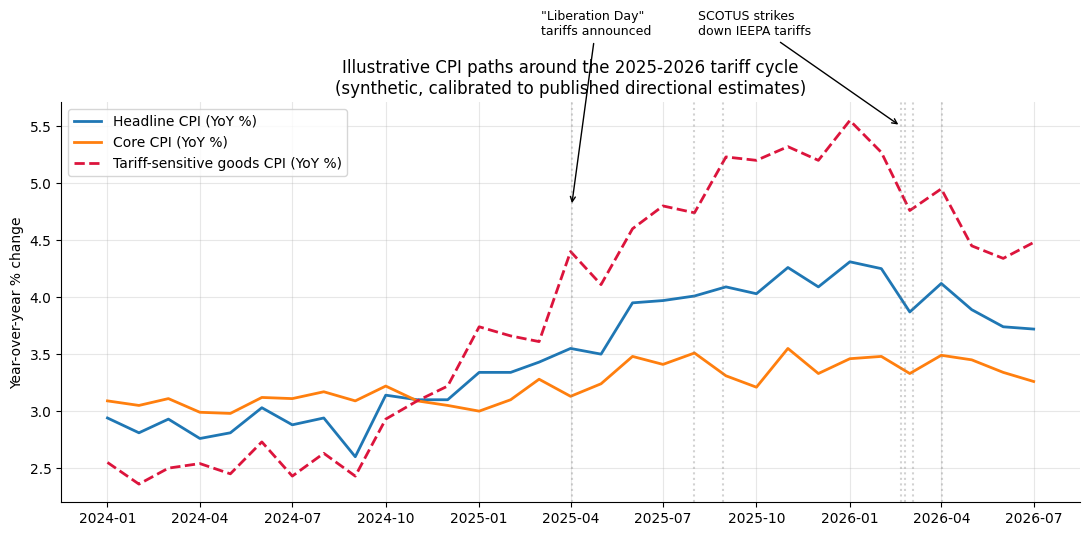

In [17]:
macro_ts = macro.set_index("month")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(macro_ts.index, macro_ts["headline_cpi_yoy"], label="Headline CPI (YoY %)", lw=2)
ax.plot(macro_ts.index, macro_ts["core_cpi_yoy"], label="Core CPI (YoY %)", lw=2)
ax.plot(macro_ts.index, macro_ts["tariff_goods_cpi_yoy"], label="Tariff-sensitive goods CPI (YoY %)",
        lw=2, linestyle="--", color="crimson")

# Annotate the REAL policy events directly on the real timeline of dates
for _, row in timeline.iterrows():
    ax.axvline(row["date"], color="gray", alpha=0.35, linestyle=":")
ax.annotate("SCOTUS strikes\ndown IEEPA tariffs", xy=(timeline["date"].iloc[3], 5.5),
            xytext=(timeline["date"].iloc[3] - pd.Timedelta(days=200), 6.3),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("\"Liberation Day\"\ntariffs announced", xy=(timeline["date"].iloc[0], 4.8),
            xytext=(timeline["date"].iloc[0] - pd.Timedelta(days=30), 6.3),
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_ylabel("Year-over-year % change")
ax.set_title("Illustrative CPI paths around the 2025-2026 tariff cycle\n(synthetic, calibrated to published directional estimates)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


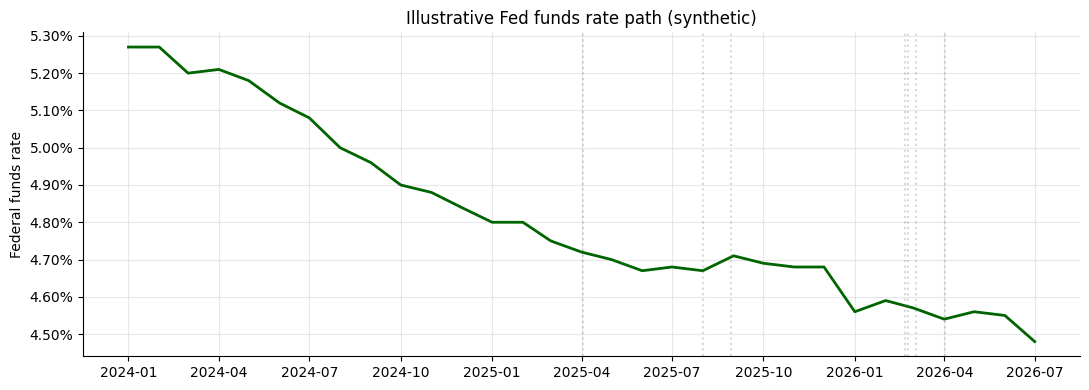

In [18]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(macro_ts.index, macro_ts["fed_funds_rate"], color="darkgreen", lw=2)
for _, row in timeline.iterrows():
    ax.axvline(row["date"], color="gray", alpha=0.3, linestyle=":")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.2f}%"))
ax.set_ylabel("Federal funds rate")
ax.set_title("Illustrative Fed funds rate path (synthetic)")
plt.tight_layout()
plt.show()


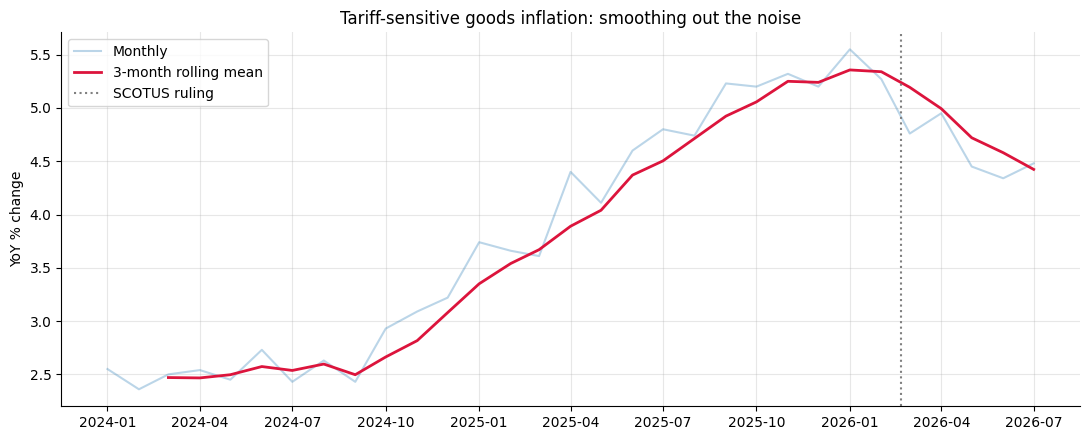

In [19]:
# resample()/rolling(): a 3-month rolling average of tariff-goods inflation,
# useful for spotting the underlying trend through month-to-month noise
macro_ts["tariff_goods_rolling_3m"] = macro_ts["tariff_goods_cpi_yoy"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(macro_ts.index, macro_ts["tariff_goods_cpi_yoy"], alpha=0.3, label="Monthly")
ax.plot(macro_ts.index, macro_ts["tariff_goods_rolling_3m"], lw=2, color="crimson", label="3-month rolling mean")
ax.axvline(timeline["date"].iloc[3], color="gray", linestyle=":", label="SCOTUS ruling")
ax.legend(); ax.set_ylabel("YoY % change")
ax.set_title("Tariff-sensitive goods inflation: smoothing out the noise")
plt.tight_layout()
plt.show()


## 6. Sector Employment Impact — groupby & Statistical Comparison

Real-world reporting (Deloitte's global outlook, cited above) specifically
named steel, aluminum, lumber, and finished autos as the hardest-hit
sectors. We compare **tariff-exposed vs. non-exposed** sectors directly.


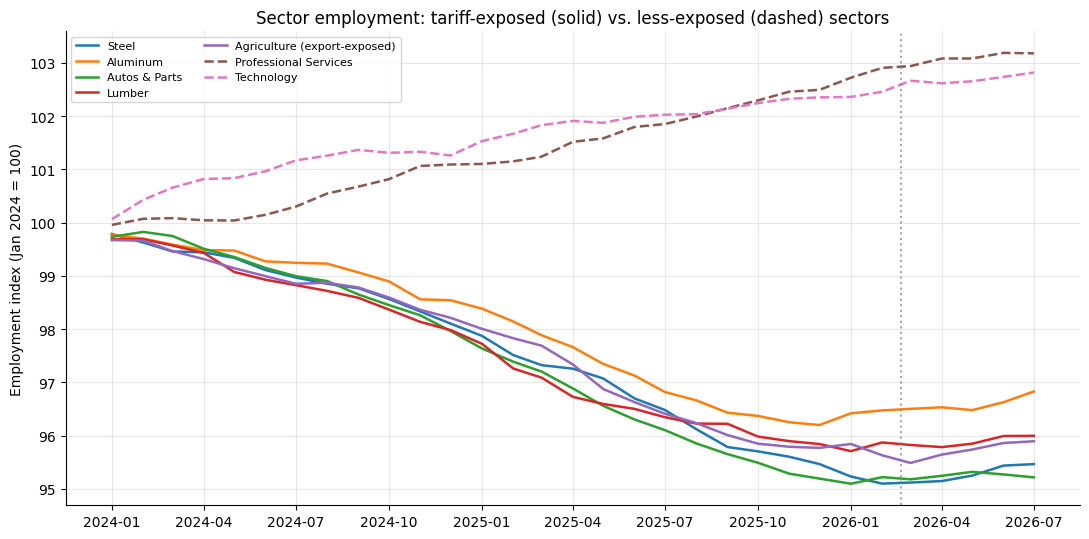

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for s in sectors:
    style = "-" if exposed[list(sectors).index(s)] else "--"
    ax.plot(months, employment[s], style, label=s, lw=1.8)
ax.axvline(timeline["date"].iloc[3], color="gray", linestyle=":", alpha=0.7)
ax.set_ylabel("Employment index (Jan 2024 = 100)")
ax.set_title("Sector employment: tariff-exposed (solid) vs. less-exposed (dashed) sectors")
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()


In [21]:
# Reshape to long/tidy form for groupby -- exactly the kind of reshape a
# real BLS-style employment analysis needs
employment_long = employment.reset_index().melt(id_vars="month", var_name="sector", value_name="index_value")
employment_long["exposed"] = employment_long["sector"].isin(sectors[exposed])

# Compare the LATEST reading vs. the pre-tariff baseline, by exposure group
latest = employment_long[employment_long["month"] == employment_long["month"].max()]
baseline = employment_long[employment_long["month"] == employment_long["month"].min()]

change = (latest.set_index("sector")["index_value"] - baseline.set_index("sector")["index_value"])
change_summary = pd.DataFrame({"exposed": employment_long.groupby("sector")["exposed"].first(),
                                 "index_change": change}).sort_values("index_change")
change_summary


,exposed,index_change
sector,,
Autos & Parts,True,-4.517484
Steel,True,-4.321820
Agriculture (export-exposed),True,-3.779992
Lumber,True,-3.691328
Aluminum,True,-2.939991
Technology,False,2.755591
Professional Services,False,3.223163


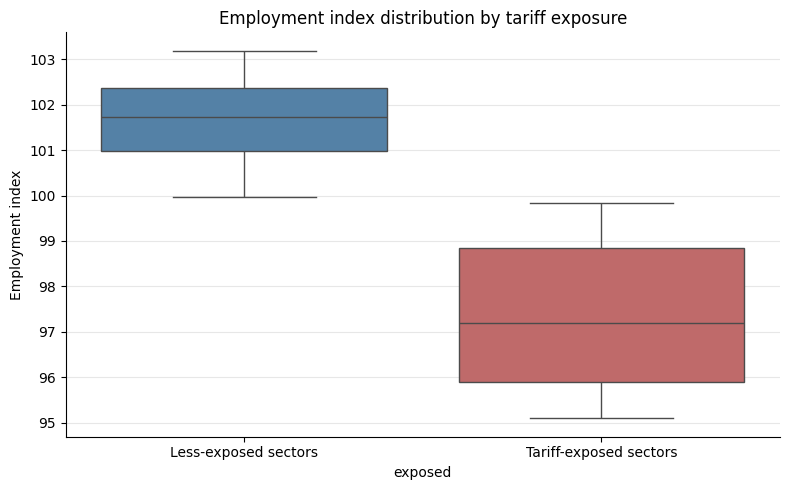

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=employment_long, x="exposed", y="index_value", hue="exposed",
            palette={True: "indianred", False: "steelblue"}, legend=False, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Less-exposed sectors", "Tariff-exposed sectors"])
ax.set_ylabel("Employment index"); ax.set_title("Employment index distribution by tariff exposure")
plt.tight_layout()
plt.show()


## 7. State-Level Geographic Trade Exposure

A bubble map of illustrative state-level exposure, biased toward the real
sector geography: Midwest auto/steel states and Farm Belt agricultural
exporters are the two groups most frequently named in tariff/retaliation
coverage.


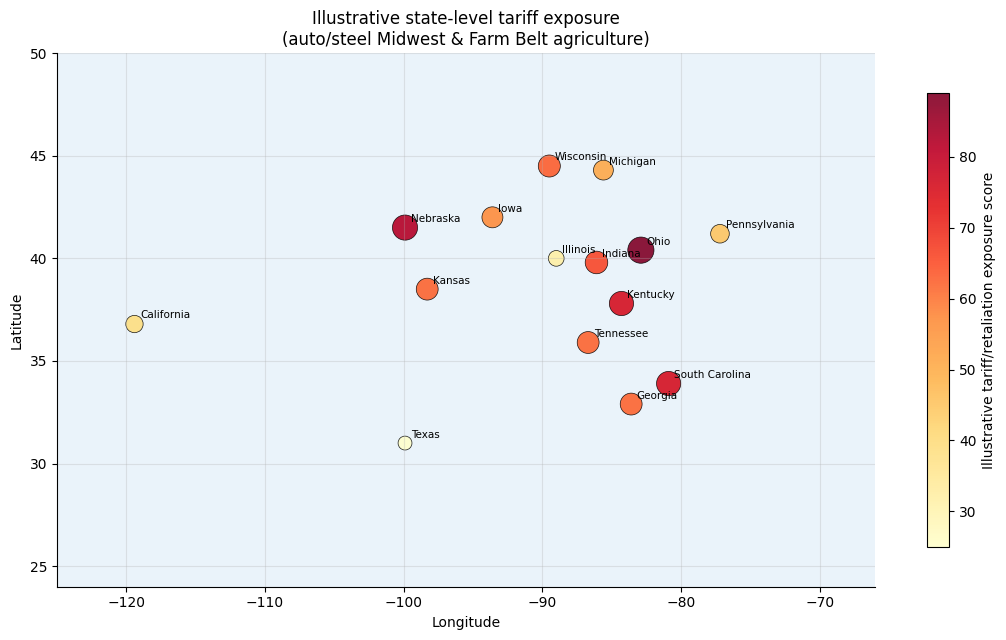

In [23]:
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(-125, -66); ax.set_ylim(24, 50)
ax.set_facecolor("#eaf3fa"); ax.grid(alpha=0.3)

sizes = state_data["exposure_score"] * 4
colors = state_data["exposure_score"]
sc = ax.scatter(state_data["lon"], state_data["lat"], s=sizes, c=colors, cmap="YlOrRd",
                 edgecolor="black", linewidth=0.5, alpha=0.9)

for _, row in state_data.iterrows():
    ax.annotate(row["state"], (row["lon"], row["lat"]), fontsize=7.5,
                xytext=(4, 4), textcoords="offset points")

cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Illustrative tariff/retaliation exposure score")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Illustrative state-level tariff exposure\n(auto/steel Midwest & Farm Belt agriculture)")
plt.tight_layout()
plt.show()


In [24]:
state_data.groupby("primary_exposure")["exposure_score"].agg(["mean", "count"]).round(1).sort_values("mean", ascending=False)


,mean,count
primary_exposure,,
Steel/Autos,89.0,1
Autos,65.5,6
Dairy/Agriculture,63.0,1
Agriculture,58.2,4
Steel,45.0,1
Electronics/Agriculture,39.0,1
Energy/Agriculture,25.0,1


## 8. Country-Level Tariff Relief — Ranking the Real Data

Back to the **real** `country_relief` table from Section 1 — sorted and
visualized directly.


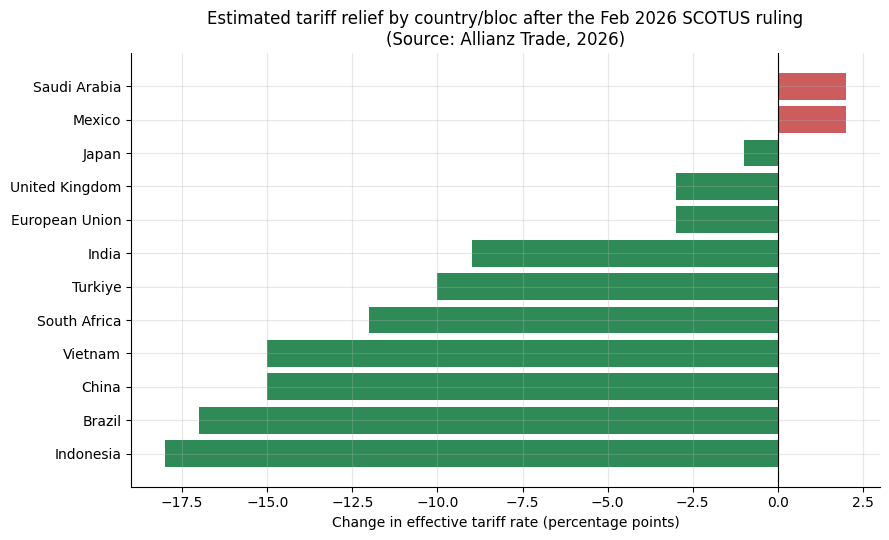

In [25]:
order = country_relief["effective_tariff_change_pp"].to_numpy().argsort()   # ascending: biggest relief first
ordered = country_relief.iloc[order]

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["seagreen" if v < 0 else "indianred" for v in ordered["effective_tariff_change_pp"]]
ax.barh(ordered["country_bloc"], ordered["effective_tariff_change_pp"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Change in effective tariff rate (percentage points)")
ax.set_title("Estimated tariff relief by country/bloc after the Feb 2026 SCOTUS ruling\n(Source: Allianz Trade, 2026)")
plt.tight_layout()
plt.show()


## 9. Fiscal Impact — Revenue Collected vs. Refund Liability

Using the **real** IEEPA revenue table from Section 1, alongside the
published refund-liability estimate.


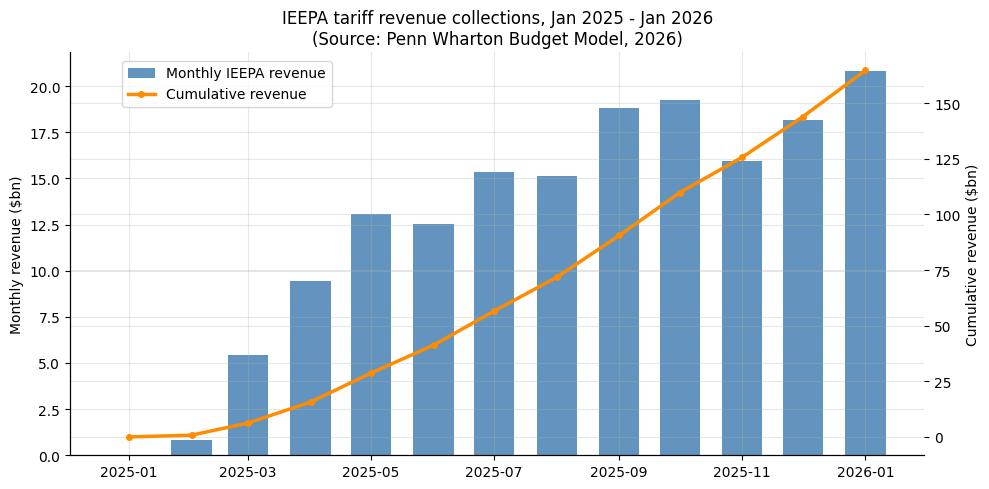

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ieepa_revenue["month"], ieepa_revenue["monthly_revenue_usd_bn"], width=20,
       color="steelblue", alpha=0.85, label="Monthly IEEPA revenue")
ax2 = ax.twinx()
ax2.plot(ieepa_revenue["month"], ieepa_revenue["cumulative_revenue_usd_bn"], color="darkorange",
         lw=2.5, marker="o", markersize=4, label="Cumulative revenue")

ax.set_ylabel("Monthly revenue ($bn)"); ax2.set_ylabel("Cumulative revenue ($bn)")
ax.set_title("IEEPA tariff revenue collections, Jan 2025 - Jan 2026\n(Source: Penn Wharton Budget Model, 2026)")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


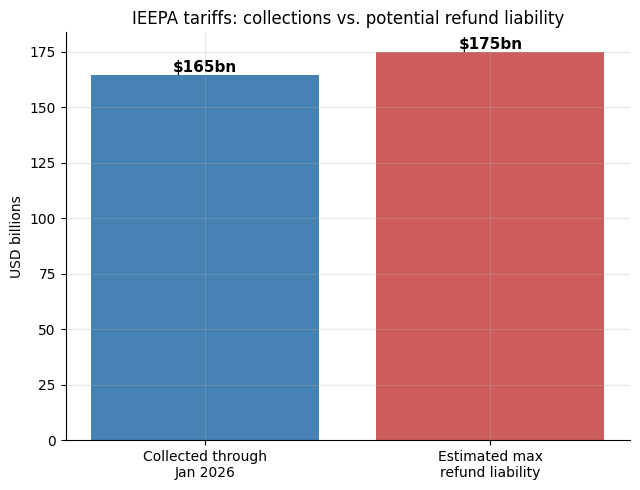

In [27]:
total_collected = ieepa_revenue["cumulative_revenue_usd_bn"].iloc[-1]
estimated_refund_liability = 175   # upper-end published estimate, Penn Wharton

fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(["Collected through\nJan 2026", "Estimated max\nrefund liability"],
               [total_collected, estimated_refund_liability], color=["steelblue", "indianred"])
for b in bars:
    ax.annotate(f"${b.get_height():.0f}bn", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("USD billions")
ax.set_title("IEEPA tariffs: collections vs. potential refund liability")
plt.tight_layout()
plt.show()


## 10. One-Page Executive Dashboard


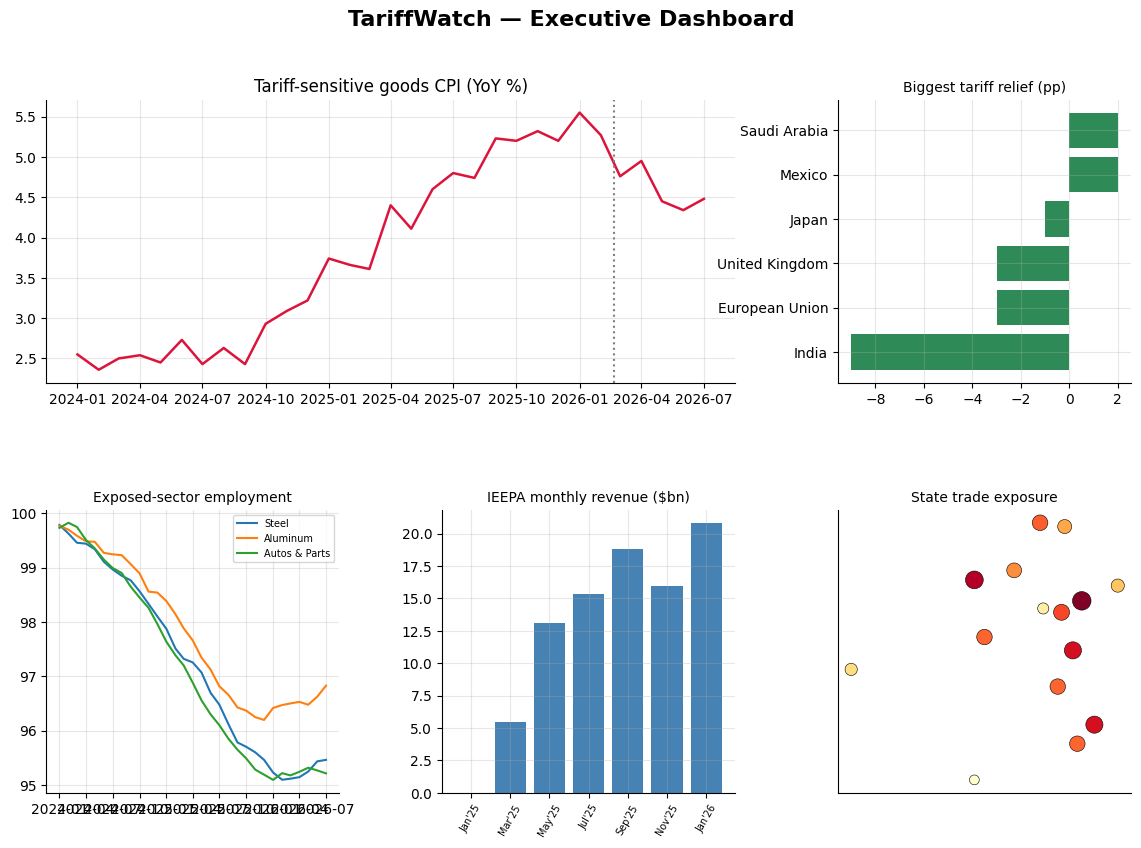

In [28]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(macro_ts.index, macro_ts["tariff_goods_cpi_yoy"], color="crimson", lw=1.8)
ax1.axvline(timeline["date"].iloc[3], color="gray", linestyle=":")
ax1.set_title("Tariff-sensitive goods CPI (YoY %)")

ax2 = fig.add_subplot(gs[0, 2])
ax2.barh(ordered["country_bloc"][-6:], ordered["effective_tariff_change_pp"][-6:], color="seagreen")
ax2.set_title("Biggest tariff relief (pp)", fontsize=10)

ax3 = fig.add_subplot(gs[1, 0])
for s in sectors[exposed][:3]:
    ax3.plot(months, employment[s], lw=1.5, label=s)
ax3.legend(fontsize=7); ax3.set_title("Exposed-sector employment", fontsize=10)

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(ieepa_revenue["month"].dt.strftime("%b'%y")[::2], ieepa_revenue["monthly_revenue_usd_bn"][::2],
        color="steelblue")
ax4.tick_params(axis="x", labelrotation=60, labelsize=7)
ax4.set_title("IEEPA monthly revenue ($bn)", fontsize=10)

ax5 = fig.add_subplot(gs[1, 2])
sc = ax5.scatter(state_data["lon"], state_data["lat"], s=state_data["exposure_score"]*2,
                   c=state_data["exposure_score"], cmap="YlOrRd", edgecolor="black", linewidth=0.4)
ax5.set_title("State trade exposure", fontsize=10)
ax5.set_xticks([]); ax5.set_yticks([])

fig.suptitle("TariffWatch — Executive Dashboard", fontsize=16, fontweight="bold")
plt.show()


## 11. Wrap-up, Caveats, and Further Resources

### What this notebook did
Starting from two small **real, cited** datasets (IEEPA revenue collections
and country-level tariff relief), we built a calibrated synthetic pipeline
covering the full analytical stack:

- **NumPy**: a country×product tariff matrix, trade-weighted effective-rate
  computation via broadcasting/aggregation, ufunc-based landed-cost and
  price pass-through modeling, and boolean masking to flag the highest-impact
  remaining tariff/volume combinations
- **pandas**: monthly macro and sector-employment time series, `groupby`
  comparisons between tariff-exposed and non-exposed sectors, resampling and
  rolling means
- **Visualization**: annotated time series tied to the real policy timeline,
  a geographic exposure bubble map, ranked bar charts of real country-level
  data, and a one-page executive dashboard

### Important caveats
- The **country×product tariff matrix, CPI subcomponents, sector employment,
  and state exposure scores are synthetic** — calibrated to be directionally
  consistent with the cited published estimates, but **not** official BLS,
  Census, or USITC data. Do not use these specific numbers for real policy
  or investment decisions.
- The **IEEPA revenue table and country-relief estimates are real**,
  reproduced from the cited sources as of when the sources were published;
  both are subject to revision as refund litigation and new tariff actions
  (e.g. the April 2026 Section 232 metals expansion) continue to unfold.
- Tariff economics is genuinely contested: reasonable analysts disagree on
  incidence (who ultimately pays), long-run reallocation effects, and
  whether industry-protection or national-security benefits offset
  near-term consumer costs. This notebook reports published estimates; it
  does not adjudicate that debate.

### Sources cited in this notebook
- Brookings, *"Brookings experts on the Supreme Court's tariff decision"*, Feb 2026
- Tax Foundation, *"Supreme Court Trump Tariffs Ruling: Analysis"*, Feb 2026
- Penn Wharton Budget Model, *"Supreme Court Tariff Ruling: IEEPA Revenue and Potential Refunds"*, Feb 2026
- Holland & Knight, *"Supreme Court Strikes Down IEEPA Tariffs"*, Feb 2026
- White & Case, *"United States terminates IEEPA-based tariffs..."*, 2026
- BDO, *"United States - Supreme Court Reins in IEEPA Tariff Authority"*, Apr 2026
- Allianz Trade, *"US Supreme Court IEEPA Tariffs"* analysis, 2026
- Deloitte Insights, *Global Economic Outlook 2026* and *US Economic Forecast Q1 2026*

### Where to go next
- Replace the synthetic tariff matrix with real USITC DataWeb or U.S.
  Customs trade data once you have API/subscription access.
- Pull real BLS CES employment data (sector-level) and real BLS CPI
  subcomponent data (e.g. the "tariff-sensitive goods" basket the Cleveland
  and San Francisco Feds have published trackers for) to replace the
  calibrated macro series.
- Extend the refund-liability analysis once the Court of International
  Trade's refund process (still unresolved as of this writing) concludes.
- Track ongoing Section 232/301 investigations (pharmaceuticals, critical
  minerals, commercial aircraft, polysilicon, semiconductors were all noted
  as "underway" in BDO's April 2026 analysis) as the next likely source of
  tariff-policy change.
